# 04 Robustness
Everything that stress-tests the headline numbers: null-target shuffles (leakage check), seed
stability for both parts, calibration, the D/E outcome-definition sensitivity, train/test feature
balance (mentor request), and the SMD check behind the slide claim. Standalone — the setup block
reruns the pipeline from `02_model.ipynb`.

The two bigger standalone checks have their own notebooks: `05_school_block_check.ipynb` and
`06_weight_sensitivity.ipynb`.

> **Shared setup.** The cells down to CELL 7 are copied verbatim from `02_model.ipynb` so this
> notebook runs standalone (separate notebooks = separate kernels). If the pipeline changes in 02,
> re-copy these cells. Everything after the setup block is this notebook's own content.

In [ ]:
# ============================================================
# CELL 0 — paths (portable: finds the repo by walking up from cwd)
# No editing needed on any machine. If it errors, open the repo
# folder itself in VS Code / Jupyter and restart the kernel.
# ============================================================
from pathlib import Path

def find_root(start=None, depth=6):
    p = start or Path.cwd()
    for _ in range(depth):
        if (p / "Data").exists() and (p / "Model").exists():
            return p
        p = p.parent
    raise FileNotFoundError(
        f"repo root not found walking up from {Path.cwd()} — "
        "in VS Code use File > Open Folder on summer26-teacher-ai-readiness, "
        "reopen this notebook, restart the kernel")

ROOT = find_root()
DATA_DIR = ROOT / "Data"                 # codebook + small CSVs
SPSS_DIR = DATA_DIR / "SPSS"             # raw TALIS .sav files (gitignored)
OUT_DIR  = DATA_DIR / "output"           # everything the notebooks produce (gitignored)
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("repo root:", ROOT)

In [ ]:
import matplotlib.pyplot as plt   # figures below need it (in 02 it arrives with the bake-off cell)

## Building the AI-module analysis sample

Q36 ("Have you used AI in your teaching?") is a **rotated** survey item, so a non-answer can mean two very different things:

- **Code 8 — "not administered":** a random ~2/3 of teachers never saw the question by design. This is *not missing data* — they were never asked — so we filter these rows out explicitly.
- **Code 9 — "omitted":** teachers who *were* asked but declined to answer.
  This is genuine outcome-missingness. We mark it `NaN` (rather than dropping
  it here) so it flows through the same complete-case filter as every other
  missing value in the assembly step.

Keeping the omitted rows at this stage keeps "not administered" and "declined"
conceptually distinct, and lets us count the omitters before they're dropped.

In [ ]:
# ============================================================
# CELL 1 — load merged file, build ai_sample
# ============================================================
import re
import numpy as np
import pandas as pd

merged = pd.read_csv(DATA_DIR / "output" / "teacher_principal_named_columns.csv",
                     encoding="utf-8-sig", low_memory=False)
assert any(c.startswith("P_TC") for c in merged.columns), "no principal columns - wrong file?"

q36_col = next(c for c in merged.columns if c.startswith("TT4G36"))
q36_num = pd.to_numeric(merged[q36_col], errors="coerce")
ai_sample = merged[q36_num != 8].copy()
ai_sample[q36_col] = pd.to_numeric(ai_sample[q36_col], errors="coerce").replace(9, np.nan)
print("administered the AI module:", len(ai_sample))

## Selecting teacher features (RQ1)

From the exploratory correlation screen (see `q36_correlations.xlsx`) plus technology-adoption theory, we select **18 teacher-level features**, one per construct, to predict AI adoption.

**We deliberately drop some candidates to avoid redundancy** — including a variable that duplicates another only inflates the model and splits its
importance across correlated columns:

- **Self-efficacy** — the subscales (T4SECLS/SEINS/SEENG) *and* overall
  **T4SELF** → we keep only **TT4G27M** (digital self-efficacy), the AI-relevant
  facet. General teaching confidence isn't specific to technology, so it's a
  weaker fit for predicting AI adoption.
- **T4JOYTCH** → dropped; near-duplicate of **T4JOBSAT** (r ≈ 0.6).
- **T4WELS** (umbrella wellbeing) → dropped in favour of the specific stress
  scales (**T4WLOADT**, **T4STBEH**).
- **T4EXINF**, **TT4G10** → dropped; overlap with **T4COLES** and **T4TNSCH**.
- **The TT4G16 hours battery** → collapsed to a single hours variable (**TT4G15**);
  the rest were near-zero in the screen.
- **TT4G50A–C** → dropped entirely (no overlap with the Q36 rotation form).

We build two derived features:
- **`prep_general`** — the mean of the six general-preparation items (TT4G07A–E, G),
  so "digital preparedness" (TT4G07F) stays a distinct predictor rather than
  being diluted by the whole battery.
- **AI-belief composites** — the ten belief items (TT4G35A–J, scored 1–4;
  code 5 = "I don't know" recoded to missing) are averaged into
  **`ai_benefit_mean`** (items A–E) and **`ai_risk_mean`** (items F–J), giving
  two interpretable scores instead of ten correlated columns.

We also constructed teacher–principal **disagreement measures** (perception gaps in participation, leadership, satisfaction), but these showed no predictive
signal in preliminary analysis and were dropped.

---

**Reasoning behind the feature selection.** The features chosen map onto established technology-adoption frameworks (TAM, Davis 1989; UTAUT,
Venkatesh et al. 2003): perceived usefulness (`ai_benefit_mean`), ease of use (`TT4G27M`, `TT4G07F`), social influence (`T4COLES`, `T4VALP`), facilitating
conditions (`TT4G21G`, AI training), and demographic moderators (`T4TAGEGR`).TALIS items serve as proxies for these constructs rather than validated scales.

In [107]:
# ============================================================
# CELL 2 — teacher features (RQ1) + prep_general + belief composites
# Definitions = official TALIS 2024 codebook labels (abbreviated)
# ============================================================
cb = pd.read_csv(DATA_DIR / "v2_talis2024_teacher_codebook.csv")

def tcol(v):
    """short code -> actual teacher column name in merged/ai_sample"""
    return next(c for c in ai_sample.columns if c.startswith(v + " ") or c == v)

# --- AI-belief COMPOSITES (mean of items; code 5 "I don't know" -> missing) ---
# Q35 scale: 1=Strongly disagree ... 4=Strongly agree, 5=I don't know (NOT on scale)
def belief_mean(items):
    B = ai_sample[[tcol(v) for v in items]].apply(pd.to_numeric, errors='coerce')
    B = B.replace(5, 2.5)                       # ← THIS LINE: "don't know" (5) -> neutral 2.5
    B = B.where(B.isin([1, 2, 2.5, 3, 4]))      # ← note 2.5 added to valid values
    return B.mean(axis=1).where(B.notna().sum(axis=1) >= 1)
ai_sample['ai_benefit_mean'] = belief_mean([f'TT4G35{c}' for c in 'ABCDE'])  # benefits
ai_sample['ai_risk_mean']    = belief_mean([f'TT4G35{c}' for c in 'FGHIJ'])  # risks/concerns

# --- general pedagogical preparation composite ---
# Q7a-e,g: prepared for content / subject pedagogy / general pedagogy /
# classroom practice / multicultural settings / student development
prep_codes = ['TT4G07A', 'TT4G07B', 'TT4G07C', 'TT4G07D', 'TT4G07E', 'TT4G07G']
P = ai_sample[[tcol(v) for v in prep_codes]].apply(pd.to_numeric, errors='coerce')
P = P.where(~P.isin([6, 8, 9]))
ai_sample['prep_general'] = P.mean(axis=1).where(P.notna().sum(axis=1) >= 4)

feature_cols = (
    # --- AI / digital core ---
    ['TT4G21G',   # Q21g: professional learning included "using AI for teaching and learning" (yes/no)
     'TT4G07F',   # Q7f: felt prepared for "use of digital resources and tools" (initial education)
     'TT4G27M']   # Q27m: self-efficacy — support learning through digital resources and tools

    # --- AI beliefs: two COMPOSITE scores (replaces the 10 Q35 items) ---
    + ['ai_benefit_mean',  # mean of Q35A-E; higher = agrees AI is beneficial
       'ai_risk_mean']     # mean of Q35F-J; higher = agrees AI is risky/concerning

    # --- derived: general pedagogical preparation ---
    + ['prep_general']

    # --- professional environment (TALIS derived scales) ---
    + ['T4COLES',   # Professional collaboration in lessons among teachers
       'T4TLEAD',   # Teacher leadership
       'T4VALP']    # Perceptions of value and policy influence
                    # NOTE: T4SELF (overall self-efficacy) dropped — overlaps with
                    # TT4G27M (digital self-efficacy), the AI-relevant facet we keep

    # --- wellbeing / stress (derived scales) ---
    + ['T4JOBSAT',  # Job satisfaction, overall
       'T4WLOADT',  # Workload stress
       'T4STBEH',   # Student behaviour stress
       'T4CHFAT']   # Change fatigue

    # --- workload ---
    + ['TT4G15']    # Q15: hours teaching at this school, most recent full week

    # --- demographics / employment (grouped) ---
    + ['T4TAGEGR',  # Teacher age (grouped)
       'T4TEMPWH',  # Employment status by working hours (grouped; CATEGORICAL)
       'T4TNSCH']   # Number of schools the teacher works at

    # --- structure ---
    + ['CNTRY']     # Country alpha code (CATEGORICAL, fixed effect)
)

withlabels = {
    'TT4G21G':         'Received AI Training',
    'ai_benefit_mean': 'AI-benefit beliefs',
    'ai_risk_mean':    'AI-risk beliefs',
    'CNTRY':           'Country',
    'TT4G27M':         'Digital self-efficacy',
    'TT4G07F':         'Digital preparedness',
    'prep_general':    'General preparation',
    'T4TAGEGR':        'Age group',
    'T4COLES':         'Professional collaboration',
    'T4TLEAD':         'Teacher leadership',
    'T4VALP':          'Perceived value & influence',
    'T4JOBSAT':        'Job satisfaction',
    'T4WLOADT':        'Workload stress',
    'T4STBEH':         'Student-behaviour stress',
    'T4CHFAT':         'Change fatigue',
    'TT4G15':          'Teaching hours',
    'T4TEMPWH':        'Employment status',
    'T4TNSCH':         'Number of schools',
}

assert len(feature_cols) == len(set(feature_cols))
print("teacher features:", len(feature_cols))   # 18

teacher features: 18


In [ ]:
# ---- sanity check (fast, safe to skip): recode loop handles every feature ----
DERIVED = ['prep_general', 'ai_benefit_mean', 'ai_risk_mean']
categoricals = ['CNTRY', 'T4SCHLOC', 'T4TEMPWH']

for v in feature_cols:
    if v in categoricals:
        status = 'categorical'
    elif v in DERIVED:
        status = 'derived (skip recode)'
    elif v in cb['variable_name'].values:
        status = 'raw + in codebook'
    else:
        status = 'WARNING: raw but NOT in codebook'
    print(f"{v:18s} {status}")

## Building the modeling sample

Here we assemble the final analysis table: the teacher features (recoding survey
missing-codes to `NaN`), attach the target `y` (1 = used AI, 0 = did not), and
keep only **complete cases** — teachers with valid values on every feature.

**Why complete-case?** The model needs all features present for each teacher, so
any row with a missing value is dropped. We report the accounting explicitly —
how many rows we start with, how many survive, and *where* the losses come from —
because complete-case selection isn't random: teachers who skip items may differ
systematically, and a reader should see the trade-off.

We also check that no country is disproportionately dropped (which would quietly
narrow what our cross-national claims cover) and that no country cell becomes too
small to model reliably. A useful check is whether the complete-case **AI-use
rate** matches the full-sample rate: if the two diverge, complete-casing is
biasing the sample toward one kind of teacher.

**Why school variables are handled separately.** Several countries (e.g. Japan,
Poland, Iceland, the Netherlands) do not report the full set of principal
(school) variables, so requiring them would drop those systems entirely and
skew the sample toward higher-data countries. We therefore keep the main model
to **teacher-level features** — retaining broad country coverage — and run the
school-context comparison separately, on the subset of teachers with complete
principal data (see the school-context section). In the current sample, Teacher's age group is missing from Singapoure respondents but we kept at the cost of it since it came as a strong predictor. 

In [111]:
# ============================================================
# CELL 4 — assembly: ONE fixed complete-case sample + accounting
# ============================================================
def col_for(v):
    if v in ai_sample.columns:          # prep_general, composites
        return v
    return tcol(v)

all_short = feature_cols #+ school_block           # teacher features only (school block is for subset analysis)
D = ai_sample[[col_for(v) for v in all_short]].copy()
D.columns = all_short

# per-variable missing codes from the codebook (raw teacher vars only)
cb_codes = {}
for _, row in cb[cb.variable_name.isin(feature_cols)].iterrows():
    cb_codes[row.variable_name] = [float(x) for x in
        re.findall(r"(\d+)\s*=", str(row.special_missing_or_skip_codes))]

categoricals = ['CNTRY', 'T4SCHLOC', 'T4TEMPWH']
DERIVED = ['prep_general', 'ai_benefit_mean', 'ai_risk_mean']   # ← already clean, skip
for v in feature_cols:
    if v in categoricals or v in DERIVED:                        # ← was: == 'prep_general'
        continue
    D[v] = pd.to_numeric(D[v], errors='coerce')
    if cb_codes.get(v):
        D[v] = D[v].where(~D[v].isin(cb_codes[v]))

D['TT4G21G'] = D['TT4G21G'].map({1: 1, 2: 0})     # yes/no -> 1/0

D['y'] = (pd.to_numeric(ai_sample[q36_col], errors='coerce') == 1).astype(float)
D.loc[ai_sample[q36_col].isna(), 'y'] = np.nan
D['IDSCHOOL'] = ai_sample[next(c for c in ai_sample.columns if c.startswith('IDSCHOOL'))]
D['CNTRY'] = D['CNTRY'].astype(str).str.strip()
D['T4TEMPWH'] = pd.to_numeric(D['T4TEMPWH'], errors='coerce').where(
    lambda s: ~s.isin([8, 9]))

# ---- missingness accounting ----
n0 = len(D)
print("worst 10 columns by missingness (%):")
print(D[all_short].isna().mean().mul(100).round(1).sort_values(ascending=False).head(10).to_string())

data = D.dropna()
print(f"\ncomplete cases: {len(data):,} of {n0:,}  ({len(data)/n0*100:.1f}%)")
print(f"AI-use rate: full {D['y'].mean():.3f}  |  complete-case {data['y'].mean():.3f}")

kept = pd.Series(D.index.isin(data.index), index=D.index)
drop_by_cntry = (1 - kept.groupby(D['CNTRY']).mean()).mul(100).round(1)
print("\ncountries losing the most rows (%):")
print(drop_by_cntry.sort_values(ascending=False).head(8).to_string())

for v in ['T4TAGEGR', 'TT4G21G']:
    print(f"{v}: kept mean {D.loc[kept, v].mean():.3f} | dropped mean {D.loc[~kept, v].mean():.3f}")

cc = data['CNTRY'].value_counts()
print("\nsmallest country cells:", cc.tail(3).to_dict())
print("countries with <200 rows:", (cc < 200).sum())

worst 10 columns by missingness (%):
TT4G21G         7.0
T4VALP          3.7
T4JOBSAT        3.6
T4CHFAT         3.5
T4STBEH         3.5
T4WLOADT        3.4
TT4G07F         3.1
T4TLEAD         2.9
prep_general    2.8
TT4G15          2.6

complete cases: 75,817 of 92,894  (81.6%)
AI-use rate: full 0.409  |  complete-case 0.414

countries losing the most rows (%):
CNTRY
NLD    100.0
SGP    100.0
HRV     56.0
SAU     31.0
SWE     30.3
ISR     28.7
XKX     28.0
ZAF     27.0
T4TAGEGR: kept mean 2.877 | dropped mean 2.942
TT4G21G: kept mean 0.414 | dropped mean 0.437

smallest country cells: {'NOR': 380, 'ISL': 343, 'MNE': 340}
countries with <200 rows: 0


## Train/test split and modeling setup

**School-grouped split.** Teachers are nested in schools, and teachers from the same school are more alike than teachers from different schools. A naïve random
split would put some teachers from a school in training and others in test letting the model learn at each school's pattern and inflating our scores. Therefore, we split by **school**: every teacher from a given school lands entirely in training *or* test, never both. An assertion confirms no school appears on both sides. 

**Consistent preprocessing (no leakage).** All preprocessing — scaling numeric features, one-hot encoding categoricals (country, employment status) — lives inside a scikit-learn `Pipeline`, fit only on the training data, so the test set never influences how features are prepared. A school-grouped 70/30 split yielded 53,188 training and 23,574 test observations with near-identical outcome prevalence (41.3% vs. 41.1%), confirming the grouped split preserved class balance despite not being stratified.

In [113]:
# ============================================================
# CELL 6 — school-grouped split + helpers (used by all comparisons)
# ============================================================
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import norm

RANDOM_STATE = 42
CATEGORICALS = ['CNTRY', 'T4TEMPWH']          # T4SCHLOC gone (school block out)

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(data, data['y'], groups=data['IDSCHOOL']))
train, test = data.iloc[tr_idx], data.iloc[te_idx]
assert not (set(train['IDSCHOOL']) & set(test['IDSCHOOL'])), "schools leak!"
print(f"train {len(train):,} | test {len(test):,}")
print(f"AI share — train {train['y'].mean():.3f} | test {test['y'].mean():.3f}")

def make_pipe(feats, clf=None):
    cat = [c for c in feats if c in CATEGORICALS]
    num = [c for c in feats if c not in CATEGORICALS]
    steps = [('num', StandardScaler(), num)]
    if cat:
        steps.append(('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat))
    if clf is None:
        clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
    return Pipeline([('prep', ColumnTransformer(steps)), ('clf', clf)])


HEADLINE_CLF = lambda: GradientBoostingClassifier(random_state=RANDOM_STATE)

def delong(y, p1, p2):
    y = np.asarray(y); pos, neg = y == 1, y == 0
    m, n = pos.sum(), neg.sum()
    def struct(p):
        x, yv = p[pos], p[neg]
        v10 = np.array([(np.sum(xi > yv) + .5*np.sum(xi == yv))/n for xi in x])
        v01 = np.array([(np.sum(x > yi) + .5*np.sum(x == yi))/m for yi in yv])
        return v10, v01, v10.mean()
    a1v,a1w,a1 = struct(np.asarray(p1)); a2v,a2w,a2 = struct(np.asarray(p2))
    s10 = np.cov(np.vstack([a1v,a2v])); s01 = np.cov(np.vstack([a1w,a2w]))
    var = (s10[0,0]+s10[1,1]-2*s10[0,1])/m + (s01[0,0]+s01[1,1]-2*s01[0,1])/n
    z = (a1-a2)/np.sqrt(var) if var > 0 else 0.0
    return a1, a2, 2*norm.sf(abs(z))

train 52,533 | test 23,284
AI share — train 0.414 | test 0.412


## Nested feature comparison

Instead of fitting one model and reading off coefficients, we build the model in
**nested tiers** — adding one conceptual block at a time, on the *same teachers*
and the *same train/test split* — and measure how much each block improves
discrimination (ROC-AUC). The gain (ΔAUC) at each step shows what that block
actually contributes.

- **A — teacher traits:** demographics, self-efficacy, collaboration, wellbeing,
  preparation — characteristics that plausibly *predate* AI adoption. This is our
  "cleanest" tier, least entangled with the outcome.
- **A + T — add AI training:** does professional development in AI predict use?
- **A + T + Bb / Br — add belief composites separately:** benefit beliefs and
  risk beliefs entered one at a time, so we can see which kind of belief carries
  the signal.
- **A + T + B — add both belief composites.**

Two features are deliberately held out of Tier A because they are the most
**entangled with the outcome**: AI training (a teacher inclined toward AI may
seek out AI training) and AI beliefs (using AI shapes what a teacher believes
about it). Measured in the same survey wave, these can't be read causally — so
Tier A gives the honest "how predictable is adoption from things adoption didn't
cause?" baseline, and the later tiers show how much predictive (not causal)
signal training and beliefs add.

## How well can we predict AI adoption — and what drives it?

We measure model quality with **ROC-AUC**: the probability the model ranks a random AI-user above a random non-user. 0.5 = coin flip, 1.0 = perfect.

**Building the model in tiers.** Rather than one black-box model, we add feature groups one at a time and watch how much each improves AUC. The *gain* at eachstep is the finding — a group that doesn't move the number, doesn't matter:

| Tier | What it adds |
|------|--------------|
| **Dummy** | baseline (random guessing) — the floor |
| **A=teacher traits** | who the teacher is (efficacy, collaboration, wellbeing, prep) |
| **A + Training** | did their professional development cover AI? |
| **A + T + Benefit beliefs** | do they think AI is useful? |
| **A + T + Risk beliefs** | do they worry about AI's risks? |
| **A + T + All beliefs** | both belief types together |


In [112]:
# ============================================================
# CELL 5 — nested model tiers
# ============================================================
# Tier A = "pre-adoption" traits: exclude AI training and belief composites
# (the features most entangled with the outcome), keep the rest.
tier_a = [c for c in feature_cols
          if c != 'TT4G21G' and c not in ('ai_benefit_mean', 'ai_risk_mean')]

feature_sets = {
    'A: teacher traits':        tier_a,
    'A+T: +AI training':        tier_a + ['TT4G21G'],
    'A+T+Bb: +benefit beliefs': tier_a + ['TT4G21G', 'ai_benefit_mean'],
    'A+T+Br: +risk beliefs':    tier_a + ['TT4G21G', 'ai_risk_mean'],
    'A+T+B: +all beliefs':      tier_a + ['TT4G21G', 'ai_benefit_mean', 'ai_risk_mean'],
}
for k, v in feature_sets.items():
    print(f"{k:28s} {len(v)} features")

A: teacher traits            15 features
A+T: +AI training            16 features
A+T+Bb: +benefit beliefs     17 features
A+T+Br: +risk beliefs        17 features
A+T+B: +all beliefs          18 features


## Nested comparison: what drives adoption?

We fit each tier on the training set and score it on the held-out test set, building up from the baseline. Each step's AUC gain shows how much that feature
block contributes.

**Two honesty checks run alongside:**
- **DeLong tests** — when a belief block adds only a small AUC bump, DeLong tells us whether that gain is statistically real or just noise. We report both the *size* of the gain and its p-value, because with a large test set even trivial differences can be "significant" — the size is what tells us if it matters.
- **Null-target test** — we shuffle the outcome labels and refit; a clean model should collapse to AUC ≈ 0.5, since there's nothing real to learn. If it scored higher, something would be leaking. (Ours passes.)

The dummy baseline sits at 0.498, confirming chance-level is ~0.50 and everything above it reflects real signal. Teacher traits alone reach 0.709, demographics/background carry meaningful information. Adding AI training lifts it to 0.777, a solid increment. Adding benefit beliefs gives the biggest jump (0.777 → 0.833), while risk beliefs alone add less (0.777 → 0.793). The full model tops out at 0.835.

In [114]:
# ============================================================
# CELL 7 — nested comparison + null-target check
# ============================================================
fitted = {}
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(train[tier_a], train['y'])
print(f"{'dummy baseline':<28} "
      f"{roc_auc_score(test['y'], dummy.predict_proba(test[tier_a])[:,1]):.3f}")

for name, feats in feature_sets.items():
    pipe = make_pipe(feats).fit(train[feats], train['y'])
    proba = pipe.predict_proba(test[feats])[:, 1]
    fitted[name] = (pipe, feats, proba)
    print(f"{name:<28} {roc_auc_score(test['y'], proba):.3f}")

# incremental belief tests
_, _, p_b = delong(test['y'].values, fitted['A+T+Bb: +benefit beliefs'][2],
                   fitted['A+T+B: +all beliefs'][2])
_, _, p_r = delong(test['y'].values, fitted['A+T+Br: +risk beliefs'][2],
                   fitted['A+T+B: +all beliefs'][2])
print(f"\nbenefits->all: DeLong p={p_b:.2e}  (does RISK add beyond benefits?)")
print(f"risks->all:    DeLong p={p_r:.2e}  (does BENEFIT add beyond risks?)")

# null-target leakage check
y_shuf = train['y'].sample(frac=1, random_state=0).values
full = feature_sets['A+T+B: +all beliefs']
null_auc = roc_auc_score(test['y'],
    make_pipe(full).fit(train[full], y_shuf).predict_proba(test[full])[:, 1])
print(f"\nnull-target AUC: {null_auc:.3f}  (expect ~0.50)")

dummy baseline               0.498
A: teacher traits            0.711
A+T: +AI training            0.778
A+T+Bb: +benefit beliefs     0.833
A+T+Br: +risk beliefs        0.793
A+T+B: +all beliefs          0.836

benefits->all: DeLong p=2.45e-11  (does RISK add beyond benefits?)
risks->all:    DeLong p=6.95e-109  (does BENEFIT add beyond risks?)

null-target AUC: 0.460  (expect ~0.50)


In [114]:
# ============================================================
# CELL 7 — nested comparison + null-target check
# ============================================================
fitted = {}
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(train[tier_a], train['y'])
print(f"{'dummy baseline':<28} "
      f"{roc_auc_score(test['y'], dummy.predict_proba(test[tier_a])[:,1]):.3f}")

for name, feats in feature_sets.items():
    pipe = make_pipe(feats).fit(train[feats], train['y'])
    proba = pipe.predict_proba(test[feats])[:, 1]
    fitted[name] = (pipe, feats, proba)
    print(f"{name:<28} {roc_auc_score(test['y'], proba):.3f}")

# incremental belief tests
_, _, p_b = delong(test['y'].values, fitted['A+T+Bb: +benefit beliefs'][2],
                   fitted['A+T+B: +all beliefs'][2])
_, _, p_r = delong(test['y'].values, fitted['A+T+Br: +risk beliefs'][2],
                   fitted['A+T+B: +all beliefs'][2])
print(f"\nbenefits->all: DeLong p={p_b:.2e}  (does RISK add beyond benefits?)")
print(f"risks->all:    DeLong p={p_r:.2e}  (does BENEFIT add beyond risks?)")

# null-target leakage check
y_shuf = train['y'].sample(frac=1, random_state=0).values
full = feature_sets['A+T+B: +all beliefs']
null_auc = roc_auc_score(test['y'],
    make_pipe(full).fit(train[full], y_shuf).predict_proba(test[full])[:, 1])
print(f"\nnull-target AUC: {null_auc:.3f}  (expect ~0.50)")

dummy baseline               0.498
A: teacher traits            0.711
A+T: +AI training            0.778
A+T+Bb: +benefit beliefs     0.833
A+T+Br: +risk beliefs        0.793
A+T+B: +all beliefs          0.836

benefits->all: DeLong p=2.45e-11  (does RISK add beyond benefits?)
risks->all:    DeLong p=6.95e-109  (does BENEFIT add beyond risks?)

null-target AUC: 0.460  (expect ~0.50)


## Headline stability across seeds

Repeating the grouped split 10 times confirms the result isn't split-dependent:
**AUC 0.833 ± 0.001** (range 0.830–0.834). A four-thousandth spread across ten
partitions — the headline is robust, not a lucky split.

In [118]:
# ============================================================
# CELL 9 — headline stability: AUC across 10 split seeds
# ============================================================
aucs = []
for seed in range(10):
    tri, tei = next(GroupShuffleSplit(1, test_size=0.30, random_state=seed)
                    .split(data, data['y'], groups=data['IDSCHOOL']))
    p = (make_pipe(full_feats)
         .fit(data.iloc[tri][full_feats], data.iloc[tri]['y'])
         .predict_proba(data.iloc[tei][full_feats])[:, 1])
    aucs.append(roc_auc_score(data.iloc[tei]['y'], p))
aucs = np.array(aucs)
print(f"test AUC over 10 seeds: {aucs.mean():.3f} ± {aucs.std():.3f} "
      f"(min {aucs.min():.3f}, max {aucs.max():.3f})")

test AUC over 10 seeds: 0.833 ± 0.001 (min 0.830, max 0.835)


> *Setup: permutation importance re-run here because it defines `proba` / `withlabels` used below.*

        feature      auc_drop           sd
ai_benefit_mean  1.338523e-01 2.575251e-03
        TT4G21G  7.941266e-02 1.565807e-03
          CNTRY  2.616132e-02 9.762351e-04
   ai_risk_mean  6.185015e-03 3.029337e-04
        TT4G27M  4.946861e-03 3.111655e-04
       T4TAGEGR  4.822238e-03 4.726133e-04
        T4COLES  1.064722e-03 2.583896e-04
       T4WLOADT  5.871555e-04 1.376055e-04
         T4VALP  4.399930e-04 1.112861e-04
        T4CHFAT  1.729043e-04 4.466008e-05
        T4TLEAD  1.530308e-04 6.324200e-05
   prep_general  9.895764e-05 3.215974e-05
         TT4G15  8.499506e-05 2.782412e-05
        T4STBEH  4.179259e-05 4.807395e-05
       T4TEMPWH  0.000000e+00 0.000000e+00
        T4TNSCH -2.230542e-07 6.717039e-07
        TT4G07F -7.324627e-06 2.633238e-05
       T4JOBSAT -1.354083e-05 2.921850e-05


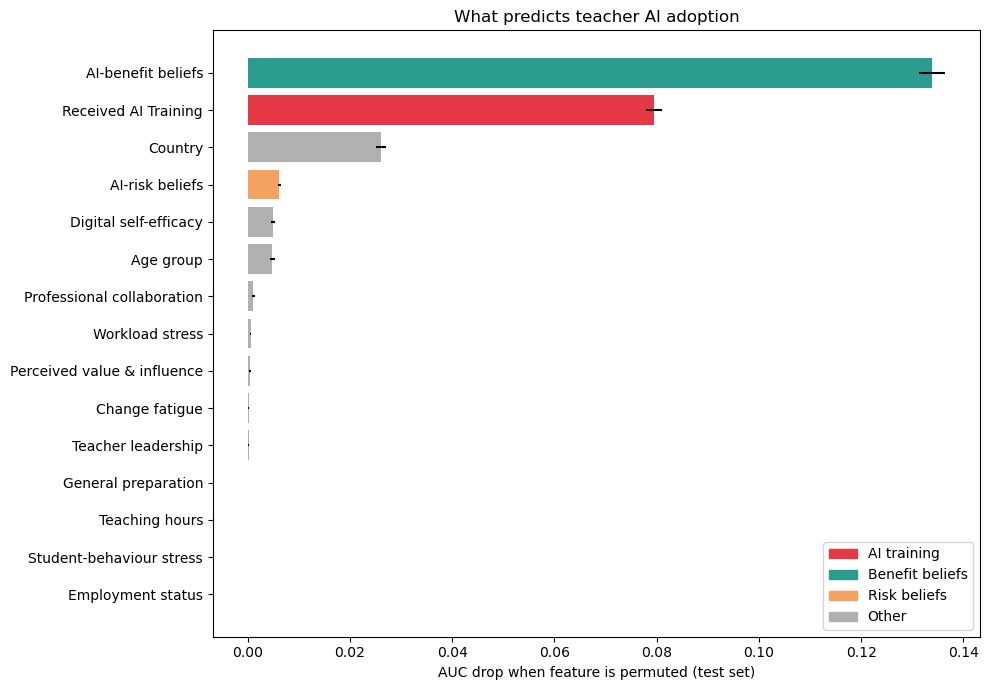

In [119]:
# ============================================================
# CELL 10 — permutation importance (test set)
# ============================================================
from sklearn.inspection import permutation_importance
from matplotlib.patches import Patch

best_name = 'A+T+B: +all beliefs'
best, best_feats, proba = fitted[best_name]

r = permutation_importance(best, test[best_feats], test['y'],
                           scoring='roc_auc', n_repeats=10,
                           random_state=RANDOM_STATE, n_jobs=-1)

imp = (pd.DataFrame({'feature': best_feats,
                     'auc_drop': r.importances_mean,
                     'sd': r.importances_std})
         .sort_values('auc_drop', ascending=False)
         .reset_index(drop=True))
print(imp.head(20).to_string(index=False))

# --- labels for the CURRENT feature set (composites, no T4SELF) ---
withlabels = {
    'TT4G21G':         'Received AI Training',
    'ai_benefit_mean': 'AI-benefit beliefs',
    'ai_risk_mean':    'AI-risk beliefs',
    'CNTRY':           'Country',
    'TT4G27M':         'Digital self-efficacy',
    'TT4G07F':         'Digital preparedness',
    'prep_general':    'General preparation',
    'T4TAGEGR':        'Age group',
    'T4COLES':         'Professional collaboration',
    'T4TLEAD':         'Teacher leadership',
    'T4VALP':          'Perceived value & influence',
    'T4JOBSAT':        'Job satisfaction',
    'T4WLOADT':        'Workload stress',
    'T4STBEH':         'Student-behaviour stress',
    'T4CHFAT':         'Change fatigue',
    'TT4G15':          'Teaching hours',
    'T4TEMPWH':        'Employment status',
    'T4TNSCH':         'Number of schools',
}

# --- color by family (composites, not individual items) ---
def fam_color(f):
    if f == 'TT4G21G':          return '#e63946'   # training — red
    if f == 'ai_benefit_mean':  return '#2a9d8f'   # benefit — teal
    if f == 'ai_risk_mean':     return '#f4a261'   # risk — amber
    return '#b0b0b0'                                # other — grey

top    = imp.head(15).iloc[::-1]
labels = top['feature'].map(withlabels).fillna(top['feature'])
colors = [fam_color(f) for f in top['feature']]

plt.figure(figsize=(10, 7))
plt.barh(labels, top['auc_drop'], xerr=top['sd'], color=colors)
plt.xlabel("AUC drop when feature is permuted (test set)")
plt.title("What predicts teacher AI adoption")
plt.legend(handles=[Patch(color='#e63946', label='AI training'),
                    Patch(color='#2a9d8f', label='Benefit beliefs'),
                    Patch(color='#f4a261', label='Risk beliefs'),
                    Patch(color='#b0b0b0', label='Other')],
           loc='lower right')
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "permutation_importance_labeled.png", dpi=150, bbox_inches="tight")
plt.show()

## Are the model's probabilities honest? (calibration)

A model can rank teachers correctly (good AUC) yet still give *dishonest* probabilities — saying "70% likely" for teachers who actually adopt only 50% of
the time. Calibration checks this.

**Calibration curve (left).** We group teachers by predicted probability and plot predicted vs. what actually happened. If the model says "60%" and 60% of those teachers really adopted, the dot sits on the diagonal. Our dots hug the diagonal closely (Brier score 0.162, where lower is better) — so when the model says 70%, about 70% really do adopt. The probabilities mean what they say.

**Score distributions (right).** The two histograms show predicted scores for actual non-users (blue) vs. actual adopters (orange). They separate cleanly —
non-users pile up at low scores, adopters at high — which is the AUC of 0.833 made visual. The overlap in the middle is where the model is genuinely uncertain.

**Binned residuals (second plot).** We sort teachers into 20 bins by predicted probability and plot the average error (actual − predicted) in each. Points
scatter close to zero with a mild upward tilt: the model slightly over-predicts for its lowest-probability teachers and slightly under-predicts for its highest —
a gentle conservatism at the extremes. The magnitude is tiny (±0.04), so it doesn't affect the conclusions.

**Bottom line:** the model isn't just accurate, its probabilities are trustworthy, and its errors have no alarming pattern.

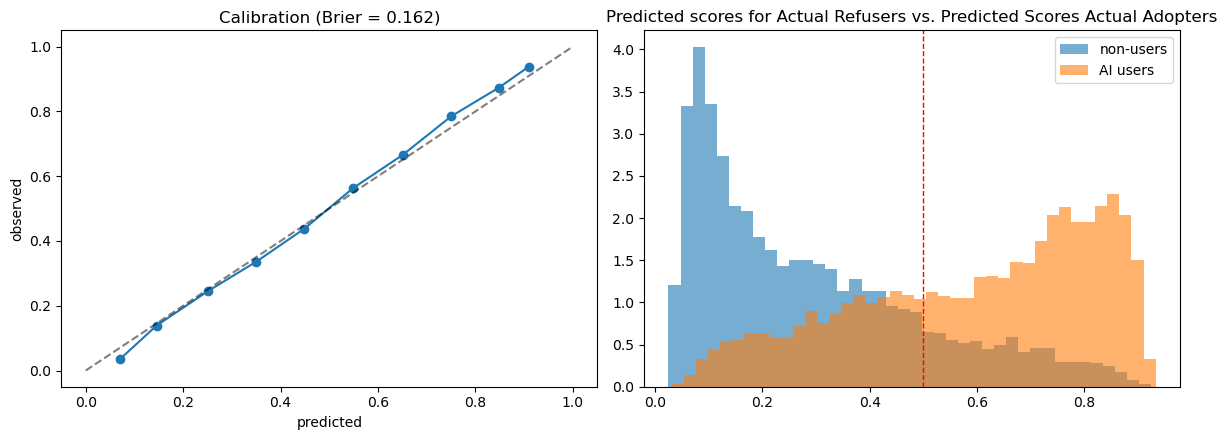

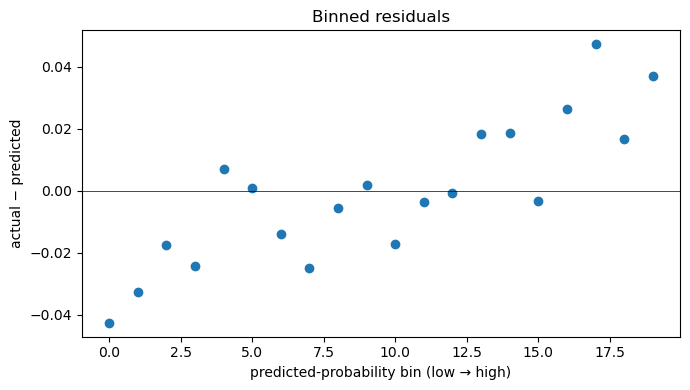

In [121]:
# ============================================================
# CELL 12 — calibration + score distributions
# ============================================================
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

best_name = 'A+T+B: +all beliefs'                  # ← fixed (was +S: +school context)
best, best_feats, proba = fitted[best_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
frac, mean_pred = calibration_curve(test['y'], proba, n_bins=10)
axes[0].plot(mean_pred, frac, 'o-'); axes[0].plot([0,1],[0,1],'k--',alpha=.5)
axes[0].set_title(f"Calibration (Brier = {brier_score_loss(test['y'], proba):.3f})")
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("observed")

axes[1].hist(proba[test['y']==0], bins=40, density=True, alpha=.6, label='non-users')
axes[1].hist(proba[test['y']==1], bins=40, density=True, alpha=.6, label='AI users')
axes[1].axvline(0.5, color='red', ls='--', lw=1)
axes[1].set_title("Predicted scores for Actual Refusers vs. Predicted Scores Actual Adopters"); axes[1].legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "calibration_scores.png", dpi=150)
plt.show()

# CELL 13b — binned residuals
te = test.copy(); te['proba'] = proba; te['resid'] = te['y'] - te['proba']
br = te.groupby(pd.qcut(te['proba'], 20), observed=True)['resid'].mean()
plt.figure(figsize=(7, 4))
plt.axhline(0, color='k', lw=.5)
plt.scatter(range(len(br)), br.values)
plt.xlabel("predicted-probability bin (low → high)"); plt.ylabel("actual − predicted")
plt.title("Binned residuals")
plt.tight_layout(); plt.show()

> *Setup for Part 2 objects (copied from `02_model.ipynb` CELLS 14–16): rebuilds the student-facing sample, split, model, and importance.*

In [ ]:
# ============================================================
# CELL 14 — Part 2 target: student-facing AI use among users
# ============================================================
from sklearn.inspection import permutation_importance

STUDENT_FACING = ['TT4G37A', 'TT4G37G', 'TT4G37H']   # assess/mark, student data, practice
TEACHER_FACING = ['TT4G37B', 'TT4G37C', 'TT4G37F']   # summarise, lesson plans, comms
AMBIGUOUS      = ['TT4G37D', 'TT4G37E']              # SEN, auto-adjust -> sensitivity only
ALL37 = STUDENT_FACING + TEACHER_FACING + AMBIGUOUS

p2 = ai_sample[pd.to_numeric(ai_sample[q36_col], errors='coerce') == 1].copy()
for c in ALL37:
    p2[c] = pd.to_numeric(p2[tcol(c)], errors='coerce').map({1: 1, 2: 0})
p2 = p2.dropna(subset=STUDENT_FACING + TEACHER_FACING)   # must answer all 6 core items
print(f"AI users with complete purpose data: {len(p2):,}")

p2['y_core']  = p2[STUDENT_FACING].max(axis=1).astype(int)
p2['y_broad'] = p2[STUDENT_FACING + AMBIGUOUS].max(axis=1).fillna(p2['y_core']).astype(int)
print(f"base rate y_core:  {p2['y_core'].mean():.3f}")
print(f"base rate y_broad: {p2['y_broad'].mean():.3f}")
flipped = (p2['y_core'] != p2['y_broad']).mean()
print(f"y_broad flips {flipped*100:.1f}% of labels (sensitivity check)")

# teacher-facing-only (the holdout group): student-facing = 0
teacher_only = ((p2['y_core'] == 0) & (p2[TEACHER_FACING].max(axis=1) == 1)).mean()
print(f"teacher-facing only (no student-facing use): {teacher_only*100:.1f}%")
# ============================================================
# CELL 15 — Part 2 sample + grouped split (teacher features only)
# ============================================================
all_short = feature_cols                               # teacher-only, matches Part 1
D2 = p2[[col_for(v) for v in all_short]].copy()
D2.columns = all_short
for v in feature_cols:
    if v in CATEGORICALS or v in ('prep_general', 'ai_benefit_mean', 'ai_risk_mean'):
        continue
    D2[v] = pd.to_numeric(D2[v], errors='coerce')
    if cb_codes.get(v):
        D2[v] = D2[v].where(~D2[v].isin(cb_codes[v]))
D2['TT4G21G'] = D2['TT4G21G'].map({1: 1, 2: 0})
D2['y'] = p2['y_core'].values
D2['IDSCHOOL'] = p2[next(c for c in p2.columns if c.startswith('IDSCHOOL'))].values
D2['CNTRY'] = D2['CNTRY'].astype(str).str.strip()
D2['T4TEMPWH'] = pd.to_numeric(D2['T4TEMPWH'], errors='coerce')
D2.loc[D2['T4TEMPWH'].isin([8, 9]), 'T4TEMPWH'] = np.nan

data2 = D2.dropna()
print(f"Part 2 complete cases: {len(data2):,} ({len(data2)/len(D2)*100:.1f}%)")
print(f"positive rate: {data2['y'].mean():.3f} | trained share: {data2['TT4G21G'].mean():.3f}")

tri2, tei2 = next(GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
                  .split(data2, data2['y'], groups=data2['IDSCHOOL']))
train2, test2 = data2.iloc[tri2], data2.iloc[tei2]
assert not (set(train2['IDSCHOOL']) & set(test2['IDSCHOOL']))
print(f"train {len(train2):,} | test {len(test2):,}")

# ============================================================
# CELL 15b — Part 2 nested comparison + null-target check
# Mirrors CELL 7, with tiers redesigned to isolate CNTRY,
# since Part 2's question is context vs individual readiness.
# Requires: train2/test2 (CELL 15), make_pipe, HEADLINE_CLF,
#           delong, tier_a, feature_sets, DummyClassifier
# ============================================================
from sklearn.metrics import average_precision_score

tier_a_nc = [f for f in tier_a if f != 'CNTRY']      # teacher traits w/o country

feature_sets2 = {
    'C: country only':          ['CNTRY'],
    'A-C: traits (no country)': tier_a_nc,
    'A: traits + country':      tier_a,
    'A+T: +AI training':        tier_a + ['TT4G21G'],
    'A+T+B: +all beliefs':      feature_sets['A+T+B: +all beliefs'],
    'A+T+B-C: full, no country': [f for f in feature_sets['A+T+B: +all beliefs']
                                  if f != 'CNTRY'],
}

fitted2 = {}
dummy2 = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy2.fit(train2[tier_a], train2['y'])
d_proba = dummy2.predict_proba(test2[tier_a])[:, 1]
print(f"{'dummy baseline':<28} AUC {roc_auc_score(test2['y'], d_proba):.3f}")

print(f"{'tier':<28} {'AUC':>6} {'PR-AUC':>7}   (base rate {test2['y'].mean():.3f})")
for name, feats in feature_sets2.items():
    pipe = make_pipe(feats, HEADLINE_CLF()).fit(train2[feats], train2['y'])
    proba = pipe.predict_proba(test2[feats])[:, 1]
    fitted2[name] = (pipe, feats, proba)
    print(f"{name:<28} {roc_auc_score(test2['y'], proba):>6.3f} "
          f"{average_precision_score(test2['y'], proba):>7.3f}")

# --- the two comparisons that carry the Part 2 thesis ---
_, _, p_ctx = delong(test2['y'].values,
                     fitted2['C: country only'][2],
                     fitted2['A+T+B: +all beliefs'][2])
print(f"\ncountry-only vs full: DeLong p={p_ctx:.2e} "
      f"(do individual features add beyond country?)")

_, _, p_ind = delong(test2['y'].values,
                     fitted2['A+T+B-C: full, no country'][2],
                     fitted2['A+T+B: +all beliefs'][2])
print(f"no-country vs full:   DeLong p={p_ind:.2e} "
      f"(does country add beyond all individual features?)")

# --- null-target leakage check (same as Part 1) ---
y_shuf2 = train2['y'].sample(frac=1, random_state=0).values
full2 = feature_sets2['A+T+B: +all beliefs']
null_auc2 = roc_auc_score(
    test2['y'],
    make_pipe(full2, HEADLINE_CLF()).fit(train2[full2], y_shuf2)
        .predict_proba(test2[full2])[:, 1])
print(f"\nnull-target AUC: {null_auc2:.3f}  (expect ~0.50)")

# ============================================================
# CELL 16 — Part 2 model + PR-AUC (dual chart -> 03_results)
# ============================================================
from sklearn.metrics import average_precision_score

feats2 = feature_sets['A+T+B: +all beliefs']           # was +S: +school context
pipe2 = make_pipe(feats2, HEADLINE_CLF()).fit(train2[feats2], train2['y'])
proba2 = pipe2.predict_proba(test2[feats2])[:, 1]
print(f"ROC-AUC: {roc_auc_score(test2['y'], proba2):.3f}")
print(f"PR-AUC:  {average_precision_score(test2['y'], proba2):.3f} "
      f"(base rate {test2['y'].mean():.3f})")

r2 = permutation_importance(pipe2, test2[feats2], test2['y'],
                            scoring='roc_auc', n_repeats=10,
                            random_state=RANDOM_STATE, n_jobs=-1)
imp2 = (pd.DataFrame({'feature': feats2, 'auc_drop': r2.importances_mean})
          .sort_values('auc_drop', ascending=False).reset_index(drop=True))
print(imp2.head(15).to_string(index=False))

# quick Part 2 model check — does GB still win?
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv2 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for nm, clf in {'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
                'RandomForest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
                'Logistic': LogisticRegression(max_iter=2000)}.items():
    s = cross_val_score(make_pipe(feats2, clf), train2[feats2], train2['y'],
                        cv=cv2, groups=train2['IDSCHOOL'], scoring='roc_auc', n_jobs=-1)
    print(f"{nm:18s} {s.mean():.3f} ± {s.std():.3f}")

In [115]:
# null-target leakage check (20 shuffles — single draws wobble ±0.03
# because the model can memorize shuffled country-level noise)
full = feature_sets['A+T+B: +all beliefs']
nulls = []
for seed in range(20):
    y_shuf = train['y'].sample(frac=1, random_state=seed).values
    nulls.append(roc_auc_score(test['y'],
        make_pipe(full).fit(train[full], y_shuf).predict_proba(test[full])[:, 1]))
print(f"\nnull-target AUC over 20 shuffles: "
      f"{np.mean(nulls):.3f} ± {np.std(nulls):.3f}  (expect ~0.50)")


null-target AUC over 20 shuffles: 0.504 ± 0.025  (expect ~0.50)


## Part 2 stability across seeds

We repeat the grouped split 10 times to confirm the result isn't split-dependent:
**AUC 0.748 ± 0.003** (range 0.742–0.752). Stable, and consistently below the
adoption model (0.833) across every seed — the depth-vs-adoption gap is real, not
a fluke of one partition.

In [127]:
# ============================================================
# CELL 17 — Part 2 seed stability (10 splits)
# ============================================================
aucs2 = []
for seed in range(10):
    tri, tei = next(GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
                    .split(data2, data2['y'], groups=data2['IDSCHOOL']))
    p = (make_pipe(feats2, HEADLINE_CLF())
         .fit(data2.iloc[tri][feats2], data2.iloc[tri]['y'])
         .predict_proba(data2.iloc[tei][feats2])[:, 1])
    aucs2.append(roc_auc_score(data2.iloc[tei]['y'], p))
aucs2 = np.array(aucs2)
print(f"Part 2 AUC over 10 seeds: {aucs2.mean():.3f} ± {aucs2.std():.3f} "
      f"(min {aucs2.min():.3f}, max {aucs2.max():.3f})")

Part 2 AUC over 10 seeds: 0.748 ± 0.003 (min 0.741, max 0.753)


## Sensitivity check: do the ambiguous items change the story?

Two of the eight AI-use purposes are genuinely ambiguous about whether they
"reach students": using AI to **support students with special education needs**
and to **automatically adjust material difficulty**. Our main outcome (`y_core`)
excludes these; here we test whether counting them as student-facing (`y_broad`)
changes the conclusions.

We refit the same model on the broader definition and compare feature importance
rankings. If the two rankings agree, our findings don't hinge on this
classification choice.

**Result — robust (Spearman ρ = 0.93).** Broadening the definition raises the
base rate (0.70 → 0.82, so these uses are common) but barely changes AUC
(0.746 → 0.752) and preserves the importance ranking. The one visible shift:
under the broader definition, **AI-benefit beliefs rise relative to country** —
which makes sense, since the ambiguous "AI helps me support students" uses are
exactly what belief-driven teachers do. The overall set of drivers is unchanged;
country and beliefs dominate either way.

y_broad sample: 30,689 | base rate 0.824  (y_core was 0.704)
y_broad ROC-AUC 0.752  (y_core 0.745)

Top 10 by y_core, with y_broad alongside:
                 y_core  y_broad
feature                         
CNTRY            0.0675   0.0355
ai_benefit_mean  0.0421   0.0946
T4COLES          0.0127   0.0124
T4TAGEGR         0.0073   0.0050
prep_general     0.0048   0.0067
T4VALP           0.0040   0.0011
TT4G21G          0.0030   0.0041
TT4G07F          0.0027   0.0023
TT4G27M          0.0019   0.0006
ai_risk_mean     0.0015   0.0040

Spearman rank correlation of importances (core vs broad): 0.926


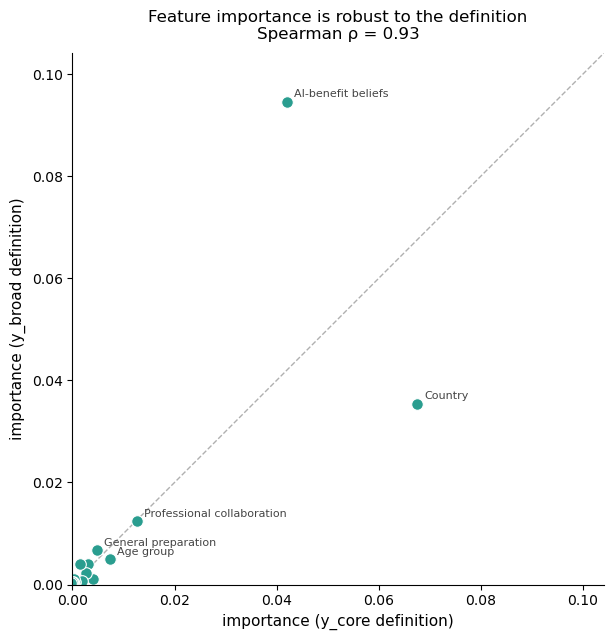

In [128]:
# ============================================================
# CELL 18 — D/E sensitivity: does the story hold under y_broad?
# ============================================================
D2b = D2.copy()
D2b['y'] = p2['y_broad'].values
data2b = D2b.dropna()
print(f"y_broad sample: {len(data2b):,} | base rate {data2b['y'].mean():.3f}  "
      f"(y_core was {data2['y'].mean():.3f})")

trib, teib = next(GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
                  .split(data2b, data2b['y'], groups=data2b['IDSCHOOL']))
train2b, test2b = data2b.iloc[trib], data2b.iloc[teib]

pipe2b = make_pipe(feats2, HEADLINE_CLF()).fit(train2b[feats2], train2b['y'])
proba2b = pipe2b.predict_proba(test2b[feats2])[:, 1]
print(f"y_broad ROC-AUC {roc_auc_score(test2b['y'], proba2b):.3f}  "
      f"(y_core {roc_auc_score(test2['y'], proba2):.3f})")     # live, not hardcoded

r2b = permutation_importance(pipe2b, test2b[feats2], test2b['y'],
                             scoring='roc_auc', n_repeats=10,
                             random_state=RANDOM_STATE, n_jobs=-1)
imp2b = (pd.DataFrame({'feature': feats2, 'auc_drop': r2b.importances_mean})
           .sort_values('auc_drop', ascending=False).reset_index(drop=True))

compare = (imp2.set_index('feature')['auc_drop'].rename('y_core').to_frame()
             .join(imp2b.set_index('feature')['auc_drop'].rename('y_broad')))
print("\nTop 10 by y_core, with y_broad alongside:")
print(compare.sort_values('y_core', ascending=False).head(10).round(4).to_string())

rho = compare['y_core'].corr(compare['y_broad'], method='spearman')
print(f"\nSpearman rank correlation of importances (core vs broad): {rho:.3f}")

# --- robustness scatter: y_core vs y_broad importance ---
fig, ax = plt.subplots(figsize=(6.5, 6.5))
mx = compare[['y_core', 'y_broad']].max().max() * 1.1
ax.plot([0, mx], [0, mx], color='#b0b0b0', ls='--', lw=1, zorder=1)
ax.scatter(compare['y_core'], compare['y_broad'],
           s=70, color='#2a9d8f', edgecolors='white', linewidths=0.8, zorder=2)
for f, row in compare.iterrows():
    if max(row['y_core'], row['y_broad']) > 0.005:
        ax.annotate(withlabels.get(f, f), (row['y_core'], row['y_broad']),
                    xytext=(5, 3), textcoords='offset points', fontsize=8, color='#444')
ax.set_xlim(0, mx); ax.set_ylim(0, mx); ax.set_aspect('equal')
ax.set_xlabel("importance (y_core definition)", fontsize=11)
ax.set_ylabel("importance (y_broad definition)", fontsize=11)
ax.set_title(f"Feature importance is robust to the definition\nSpearman ρ = {rho:.2f}",
             fontsize=12, pad=10)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "part2_sensitivity_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

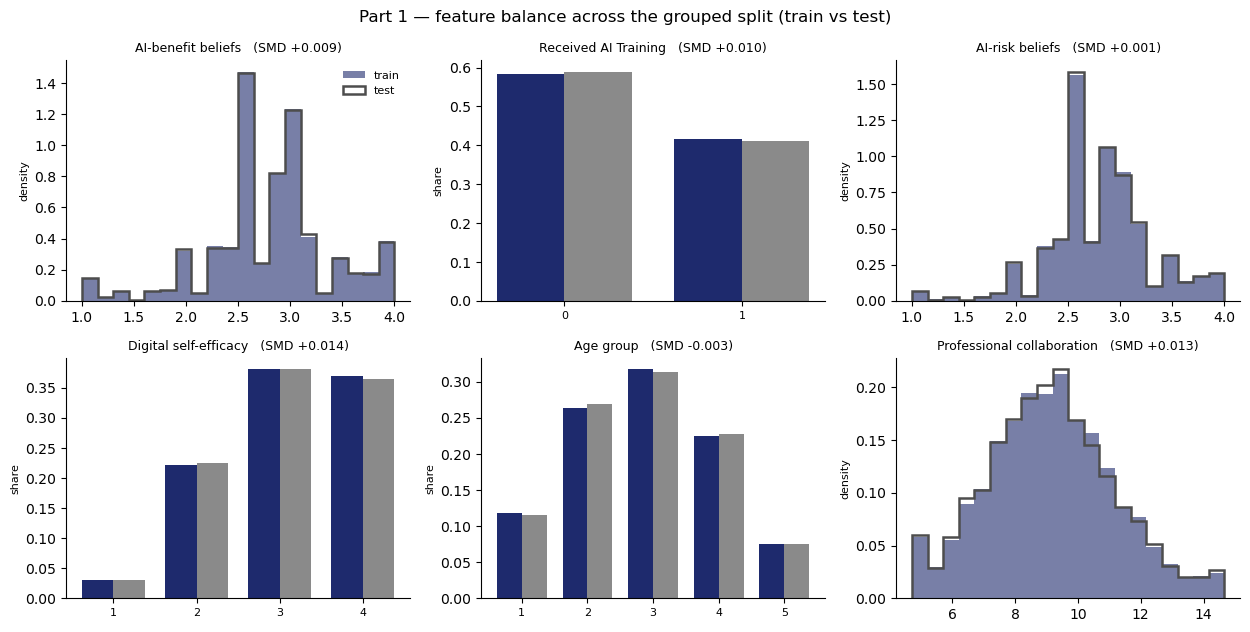

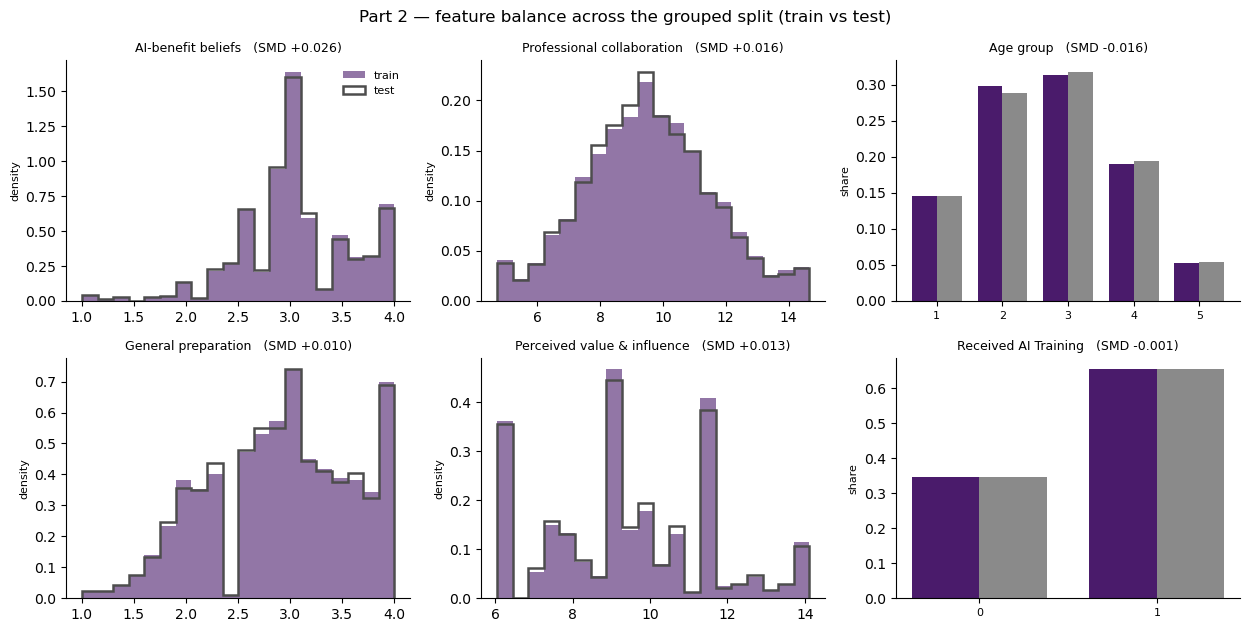

  part                     feature  train_mean  test_mean  train_sd  test_sd     SMD  abs_SMD        status
Part 1          Teacher leadership     12.2687    12.2300    1.9694   1.9556  0.0197   0.0197 well balanced
Part 1 Perceived value & influence      9.0646     9.0258    2.0354   2.0179  0.0191   0.0191 well balanced
Part 1       Digital self-efficacy      3.0895     3.0782    0.8369   0.8390  0.0135   0.0135 well balanced
Part 1    Student-behaviour stress      9.1784     9.2053    1.9938   1.9935 -0.0135   0.0135 well balanced
Part 1  Professional collaboration      9.1414     9.1144    2.0425   2.0564  0.0132   0.0132 well balanced
Part 1        Digital preparedness      2.5248     2.5131    1.0121   1.0106  0.0116   0.0116 well balanced
Part 1        Received AI Training      0.4158     0.4107    0.4929   0.4920  0.0104   0.0104 well balanced
Part 1          AI-benefit beliefs      2.7768     2.7712    0.5964   0.5984  0.0094   0.0094 well balanced
Part 1             Workload 

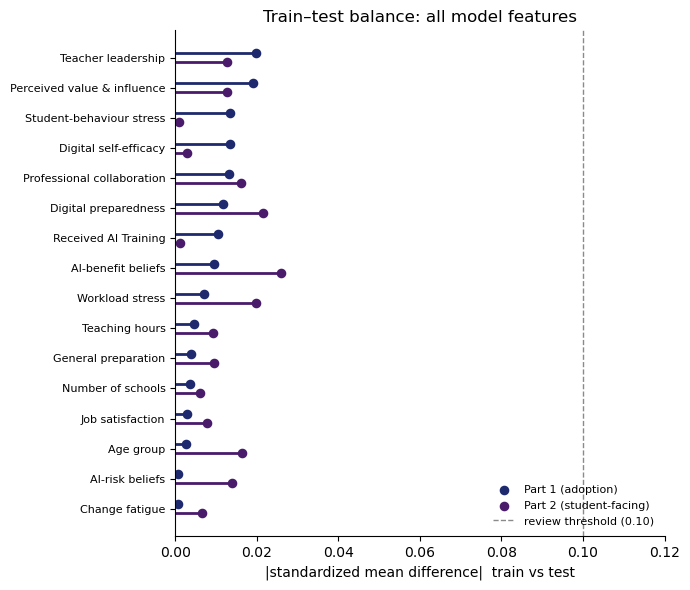

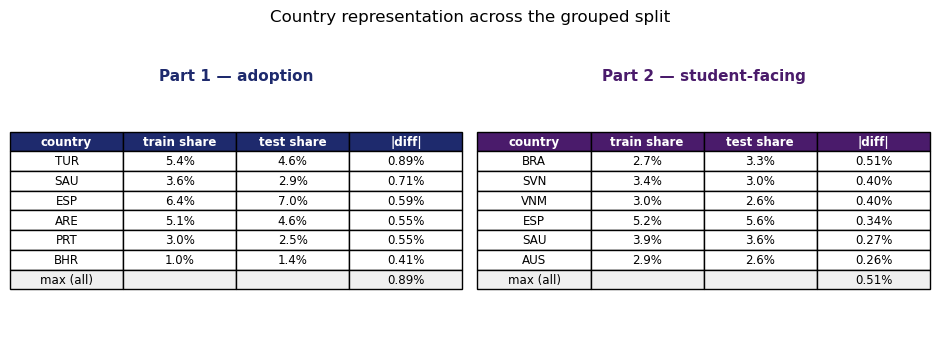


Part 1 max country-share diff: 0.0089
Part 2 max country-share diff: 0.0051


In [132]:
# ============================================================
# CELL 21 — feature balance: train vs test (mentor request)
# Grouped-by-school split could in principle skew features;
# this shows it doesn't. SMD = standardized mean difference,
# |SMD| < 0.10 is the usual "balanced" threshold.
# Pooled SD is n-weighted (Cohen's) to match the EDA-side balance check.
# Outputs: two 6-panel grids (top features), country table (PNG),
#          all-feature summary table (CSV) + all-feature SMD lollipop (PNG)
# ============================================================
NAVY, MAROON  = '#1E2A6D', '#9B1B4A'   # Part 1 family
PURPLE, LILAC = '#4A1B6B', '#9B6BC3'   # Part 2 family
GRAY = '#8A8A8A'                        # neutral / reference

NAME = {
    'TT4G21G':         'Received AI Training',
    'ai_benefit_mean': 'AI-benefit beliefs',
    'ai_risk_mean':    'AI-risk beliefs',
    'CNTRY':           'Country',
    'TT4G27M':         'Digital self-efficacy',
    'TT4G07F':         'Digital preparedness',
    'prep_general':    'General preparation',
    'T4TAGEGR':        'Age group',
    'T4COLES':         'Professional collaboration',
    'T4TLEAD':         'Teacher leadership',
    'T4VALP':          'Perceived value & influence',
    'T4JOBSAT':        'Job satisfaction',
    'T4WLOADT':        'Workload stress',
    'T4STBEH':         'Student-behaviour stress',
    'T4CHFAT':         'Change fatigue',
    'TT4G15':          'Teaching hours',
    'T4TEMPWH':        'Employment status',
    'T4TNSCH':         'Number of schools',
}

def smd(a, b):
    # n-weighted pooled SD (Cohen's) — same formula as the EDA balance cell
    n1, n2 = len(a), len(b)
    sp = np.sqrt(((n1-1)*a.var(ddof=1) + (n2-1)*b.var(ddof=1)) / (n1+n2-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else 0.0

def balance_grid(df_tr, df_te, feats_to_show, tr_color, title, fname, ncols=3):
    n = len(feats_to_show)
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, f in zip(axes, feats_to_show):
        tr, te = df_tr[f].dropna(), df_te[f].dropna()
        if df_tr[f].nunique() <= 8:
            # discrete -> side-by-side share bars
            cats = sorted(pd.concat([tr, te]).unique())
            x = np.arange(len(cats)); w = 0.38
            ax.bar(x - w/2, [(tr == c).mean() for c in cats], w, color=tr_color, label='train')
            ax.bar(x + w/2, [(te == c).mean() for c in cats], w, color=GRAY,     label='test')
            ax.set_xticks(x); ax.set_xticklabels([f"{c:g}" for c in cats], fontsize=8)
            ax.set_ylabel("share", fontsize=8)
        else:
            # continuous -> filled train + outlined test (reads cleaner in overlap)
            bins = np.histogram_bin_edges(pd.concat([tr, te]), bins=20)
            ax.hist(tr, bins=bins, density=True, alpha=0.6, color=tr_color, label='train')
            ax.hist(te, bins=bins, density=True, histtype='step', lw=1.8,
                    color='#4d4d4d', label='test')
            ax.set_ylabel("density", fontsize=8)
        ax.set_title(f"{NAME.get(f, f)}   (SMD {smd(tr, te):+.3f})", fontsize=9)
        for s in ['top', 'right']:
            ax.spines[s].set_visible(False)

    for ax in axes[n:]:
        ax.set_visible(False)
    axes[0].legend(fontsize=8, frameon=False)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(DATA_DIR / "output" / fname, dpi=150, bbox_inches='tight')
    plt.show()

# top non-country features by permutation importance
top1 = ['ai_benefit_mean', 'TT4G21G', 'ai_risk_mean',
        'TT4G27M', 'T4TAGEGR', 'T4COLES']
top2 = ['ai_benefit_mean', 'T4COLES', 'T4TAGEGR',
        'prep_general', 'T4VALP', 'TT4G21G']

balance_grid(train,  test,  top1, NAVY,
             "Part 1 — feature balance across the grouped split (train vs test)",
             "part1_feature_balance.png")
balance_grid(train2, test2, top2, PURPLE,
             "Part 2 — feature balance across the grouped split (train vs test)",
             "part2_feature_balance.png")


# ---- (#1) overall feature-balance summary: ALL numeric features, both parts ----
num_feats = [f for f in feats if f not in ('CNTRY', 'T4TEMPWH')]

def balance_summary(df_tr, df_te, part_label):
    rows = []
    for f in num_feats:
        tr, te = df_tr[f].dropna(), df_te[f].dropna()
        s = smd(tr, te)
        rows.append({'part': part_label,
                     'feature': NAME.get(f, f),
                     'train_mean': tr.mean(), 'test_mean': te.mean(),
                     'train_sd': tr.std(ddof=1), 'test_sd': te.std(ddof=1),
                     'SMD': s, 'abs_SMD': abs(s),
                     'status': 'well balanced' if abs(s) < 0.10
                               else 'review'    if abs(s) < 0.20
                               else 'potential imbalance'})
    return pd.DataFrame(rows)

balance_tbl = pd.concat([balance_summary(train,  test,  'Part 1'),
                         balance_summary(train2, test2, 'Part 2')],
                        ignore_index=True).round(4)
balance_tbl.to_csv(DATA_DIR / "output" / "train_test_balance_summary.csv", index=False)

print(balance_tbl.sort_values(['part', 'abs_SMD'], ascending=[True, False])
                 .to_string(index=False))
for p in ['Part 1', 'Part 2']:
    sub = balance_tbl[balance_tbl['part'] == p]
    print(f"\n{p}: {(sub['abs_SMD'] < 0.10).sum()}/{len(sub)} features well balanced | "
          f"largest {sub.loc[sub['abs_SMD'].idxmax(), 'feature']} "
          f"({sub['abs_SMD'].max():.3f})")


# ---- (#4) absolute-SMD lollipop: ALL features, both parts, one figure ----
all_smd1 = dict(zip(balance_tbl.loc[balance_tbl['part'] == 'Part 1', 'feature'],
                    balance_tbl.loc[balance_tbl['part'] == 'Part 1', 'abs_SMD']))
all_smd2 = dict(zip(balance_tbl.loc[balance_tbl['part'] == 'Part 2', 'feature'],
                    balance_tbl.loc[balance_tbl['part'] == 'Part 2', 'abs_SMD']))

order = sorted(all_smd1, key=all_smd1.get)
y = np.arange(len(order))

fig, ax = plt.subplots(figsize=(7, 6))
ax.hlines(y + 0.15, 0, [all_smd1[f] for f in order], color=NAVY,   lw=2)
ax.scatter([all_smd1[f] for f in order], y + 0.15, color=NAVY,   s=35, label='Part 1 (adoption)')
ax.hlines(y - 0.15, 0, [all_smd2[f] for f in order], color=PURPLE, lw=2)
ax.scatter([all_smd2[f] for f in order], y - 0.15, color=PURPLE, s=35, label='Part 2 (student-facing)')
ax.axvline(0.10, ls='--', lw=1, color=GRAY, label='review threshold (0.10)')
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel("|standardized mean difference|  train vs test")
ax.set_title("Train–test balance: all model features")
ax.set_xlim(0, 0.12)
ax.legend(fontsize=8, frameon=False, loc='lower right')
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "smd_all_features.png", dpi=150, bbox_inches='tight')
plt.show()


# ---- country representation across the grouped split: BOTH parts, one table ----
def ctry_balance(df_tr, df_te):
    cb = (pd.concat([df_tr['CNTRY'].value_counts(normalize=True).rename('train'),
                     df_te['CNTRY'].value_counts(normalize=True).rename('test')], axis=1)
            .fillna(0))
    cb['abs_diff'] = (cb['train'] - cb['test']).abs()
    return cb.sort_values('abs_diff', ascending=False)

cb1, cb2 = ctry_balance(train, test), ctry_balance(train2, test2)
TOP_K = 6  # worst offenders per part; rest summarized in the max row

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
for ax, cb, label, hdr_color in [(axes[0], cb1, "Part 1 — adoption", NAVY),
                                 (axes[1], cb2, "Part 2 — student-facing", PURPLE)]:
    ax.axis('off')
    top = cb.head(TOP_K)
    rows = [[c, f"{r.train:.1%}", f"{r.test:.1%}", f"{r.abs_diff:.2%}"]
            for c, r in top.iterrows()]
    rows.append(["max (all)", "", "", f"{cb['abs_diff'].max():.2%}"])
    tbl = ax.table(cellText=rows,
                   colLabels=["country", "train share", "test share", "|diff|"],
                   loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1, 1.25)
    for j in range(4):                       # header styling
        tbl[0, j].set_facecolor(hdr_color)
        tbl[0, j].set_text_props(color='white', weight='bold')
    for j in range(4):                       # summary row styling
        tbl[len(rows), j].set_facecolor('#efefef')
    ax.text(0.5, 1.06, label, transform=ax.transAxes,
            ha='center', fontsize=11, weight='bold', color=hdr_color)

fig.suptitle("Country representation across the grouped split", fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "country_split_balance.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPart 1 max country-share diff: {cb1['abs_diff'].max():.4f}")
print(f"Part 2 max country-share diff: {cb2['abs_diff'].max():.4f}")

In [ ]:
# ---- sanity check (fast, safe to skip): P1/P2 feature sets line up ----
p1_feats = feature_sets['A+T+B: +all beliefs']          # Part 1 full model
p2_feats = feats2                                        # Part 2 (CELL 16)

print(f"Part 1 ({len(p1_feats)}):", p1_feats)
print(f"\nPart 2 ({len(p2_feats)}):", p2_feats)
print("\nin P1 not P2:", set(p1_feats) - set(p2_feats))
print("in P2 not P1:", set(p2_feats) - set(p1_feats))
print("\nmissing from data  (P1):", [f for f in p1_feats if f not in data.columns])
print("missing from data2 (P2):", [f for f in p2_feats if f not in data2.columns])

In [142]:
# max |SMD| per part — matches the slide claim?
for nm, tr, te_ in [('P1', train, test), ('P2', train2, test2)]:
    num = [f for f in feature_cols if f not in CATEGORICALS]
    smd = ((tr[num].mean() - te_[num].mean()).abs()
           / pd.concat([tr[num], te_[num]]).std())
    print(nm, 'max |SMD| =', round(smd.max(), 3), '(', smd.idxmax(), ')')

P1 max |SMD| = 0.02 ( T4TLEAD )
P2 max |SMD| = 0.026 ( ai_benefit_mean )
